# ARCCRAFT empirical benchmark and reproducibility audit

**Authors:** Elia Batako and Manuel Ntumba  
**Paper:** *Procedural Stress Testing of Actuarial Models: Design and Validation of the ARCCRAFT Framework*

## TL;DR

This notebook evaluates only claims that can be tested with the material currently available. It (i) audits the public motor portfolio, (ii) performs two rolling-origin forecasts and a 2024 benchmark comparison, (iii) maps a frequency–severity stress surface, and (iv) tests exact replay, seed sensitivity, validator sensitivity, and Failure Atlas accounting in the synthetic engine.

The notebook does **not** treat the synthetic grammar as an empirically validated model. With only three calendar years, predictive coverage, tail calibration, and comparative superiority cannot be established. All displayed values are regenerated from the local database and code at execution time.

## 1. Context and methods

The empirical design distinguishes two evidence layers:

1. **External portfolio layer.** Calibration uses earlier years and evaluation uses a later year without recalibration. The ARCCRAFT frequency–severity implementation is compared with transparent deterministic reference forecasts. The two available forecast origins (2023 and 2024) are reported individually; they are not enough for a stable estimate of interval coverage.
2. **Synthetic procedural layer.** The experiment tests software properties and scenario behaviour: exact same-seed replay, sensitivity to changing the seed, structural validation, failure-gate accounting, and independence of reverse-stress output from prior random-number consumption.

The principal stochastic forecast assumes a Poisson aggregate count and a lognormal severity proxy, with a conditional normal approximation for aggregate incurred loss. The stress surface changes only frequency and severity multipliers. Consequently, the surface is a model-implied sensitivity analysis, not an observed causal relationship.

In [1]:
from pathlib import Path
import copy, hashlib, json, math, sqlite3, subprocess, sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
OUT = REPO.parents[1] / "ARCCRAFT"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(REPO))

from backend import data_service
from backend.model_service import arccraft_empirical_motor
from backend.engine import arccraft_engine as engine

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.style.use("seaborn-v0_8-whitegrid")

MASTER_SEED = 20260825
FORECAST_SEED = 42
N_FORECAST = 50_000
N_SYNTHETIC = 3_000

## 2. Data provenance and quality audit

In [2]:
db_path = REPO / "data" / "platform.db"
db_sha256 = hashlib.sha256(db_path.read_bytes()).hexdigest()
git_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO, text=True).strip()
git_diff = subprocess.check_output(["git", "diff", "--binary"], cwd=REPO)
git_diff_sha256 = hashlib.sha256(git_diff).hexdigest()
engine_sha256 = hashlib.sha256((REPO / "backend" / "engine" / "arccraft_engine.py").read_bytes()).hexdigest()
service_sha256 = hashlib.sha256((REPO / "backend" / "model_service.py").read_bytes()).hexdigest()

with sqlite3.connect(db_path) as con:
    integrity = con.execute("PRAGMA integrity_check").fetchone()[0]
    audit = con.execute('''
        SELECT COUNT(*) AS rows,
               COUNT(DISTINCT insured_id) AS insureds,
               MIN(year) AS min_year,
               MAX(year) AS max_year,
               SUM(CASE WHEN total_exposure IS NULL OR total_premium IS NULL OR total_claims IS NULL OR total_incurred IS NULL THEN 1 ELSE 0 END) AS critical_null_rows,
               SUM(CASE WHEN total_exposure < 0 OR total_premium < 0 OR total_claims < 0 OR total_incurred < 0 THEN 1 ELSE 0 END) AS negative_rows
        FROM motor_portfolio
    ''').fetchone()
    duplicates = con.execute('''
        SELECT COUNT(*) FROM (
          SELECT insured_id, year, COUNT(*) n
          FROM motor_portfolio GROUP BY insured_id, year HAVING n > 1
        )
    ''').fetchone()[0]

provenance = pd.DataFrame({
    "item": ["database", "database_sha256", "git_commit", "working_diff_sha256",
             "arccraft_engine_sha256", "model_service_sha256", "sqlite_integrity", "duplicate_insured_year"],
    "value": [str(db_path), db_sha256, git_commit, git_diff_sha256,
              engine_sha256, service_sha256, integrity, duplicates],
})
quality = pd.DataFrame([audit], columns=["rows", "insureds", "min_year", "max_year", "critical_null_rows", "negative_rows"])
display(provenance)
display(quality)
assert integrity == "ok" and duplicates == 0 and audit[4] == 0 and audit[5] == 0

,item,value
0,database,D:\Projet\SOUTENANCE\POC_ARCCRAFT\mapta-compas...
1,database_sha256,c2bf54460e0613c7ad12eab7d0169ffc4259e121ae3ce8...
2,git_commit,b3df670227efa4aecf5383979b90f3eab15ae528
3,working_diff_sha256,7aaa30050600434d7695244574bae9a859084c633d0464...
4,arccraft_engine_sha256,985d6bc0f7f04a9cdeb1e6e1ad972d72cd64801d0a9a92...
5,model_service_sha256,96c227f3c018542d7aa298d025267dec0e1b4efa8e6926...
6,sqlite_integrity,ok
7,duplicate_insured_year,0


,rows,insureds,min_year,max_year,critical_null_rows,negative_rows
0,354140,185678,2022,2024,0,0


,year,policy_rows,insureds,exposure,premium,claims,incurred,claim_frequency,avg_severity,loss_ratio
0,2022,67172,67172,"41,912.495890","18,697,928.342009",12665,"12,270,105.055000",0.302177,968.819981,0.656228
1,2023,118835,118835,"82,399.038356","35,344,308.084516",25158,"23,488,354.354000",0.305319,933.633610,0.664558
2,2024,168133,168133,"126,014.364384","51,037,433.000661",39276,"38,106,351.280000",0.311679,970.219760,0.746635


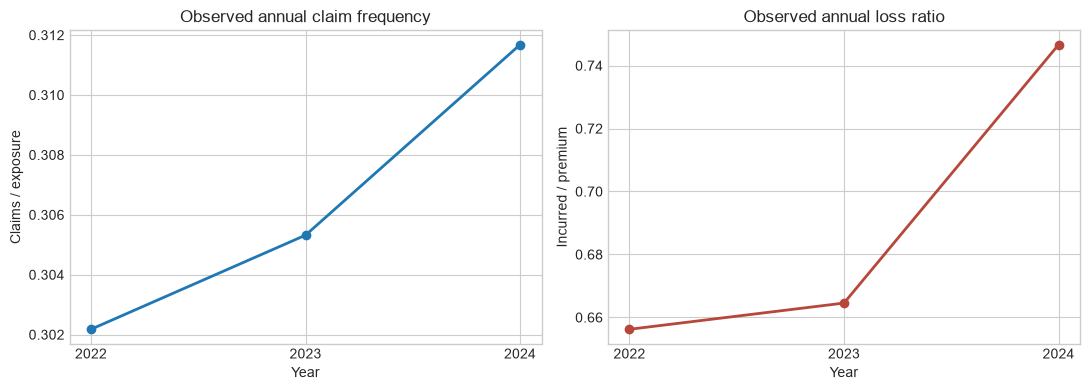

In [3]:
with sqlite3.connect(db_path) as con:
    annual = pd.read_sql_query('''
        SELECT year,
               COUNT(*) AS policy_rows,
               COUNT(DISTINCT insured_id) AS insureds,
               SUM(total_exposure) AS exposure,
               SUM(total_premium) AS premium,
               SUM(total_claims) AS claims,
               SUM(total_incurred) AS incurred
        FROM motor_portfolio
        GROUP BY year ORDER BY year
    ''', con)

annual["claim_frequency"] = annual["claims"] / annual["exposure"]
annual["avg_severity"] = annual["incurred"] / annual["claims"]
annual["loss_ratio"] = annual["incurred"] / annual["premium"]
display(annual)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(annual.year, annual.claim_frequency, marker="o", lw=2, label="Claim frequency")
axes[0].set(title="Observed annual claim frequency", xlabel="Year", ylabel="Claims / exposure", xticks=annual.year)
axes[1].plot(annual.year, annual.loss_ratio, marker="o", lw=2, color="#b5483a", label="Loss ratio")
axes[1].set(title="Observed annual loss ratio", xlabel="Year", ylabel="Incurred / premium", xticks=annual.year)
fig.tight_layout()
fig.savefig(FIG / "observed_annual_metrics.png", dpi=180, bbox_inches="tight")
plt.show()

The database passes the mechanical checks above. This does not prove semantic correctness or representativeness. In particular, the available portfolio contains only three years and the number of policy rows and exposure increases sharply across years; the experiment therefore evaluates aggregate transfer across changing portfolio volumes, not stationarity of a fixed cohort.

## 3. Out-of-sample forecasts and transparent benchmarks

In [4]:
def pct_error(pred, obs):
    return 100.0 * (pred - obs) / obs

rolling_rows = []
forecast_outputs = {}
for cal_start, cal_end, target in [(2022, 2022, 2023), (2022, 2023, 2024)]:
    out = arccraft_empirical_motor(
        cal_start, cal_end, target, n_simulations=N_FORECAST, seed=FORECAST_SEED,
        frequency_multiplier=1.0, severity_multiplier=1.0,
    )
    forecast_outputs[target] = out
    rolling_rows.append({
        "calibration": f"{cal_start}-{cal_end}",
        "target": target,
        "observed_claims": out["validation"]["observed_claims"],
        "predicted_claims": out["predicted_claim_count"]["mean"],
        "claim_error_pct": out["validation"]["claim_count_error_pct"],
        "claims_in_95_interval": out["validation"]["observed_claims_in_95_interval"],
        "observed_incurred": out["validation"]["observed_incurred"],
        "predicted_incurred": out["predicted_incurred"]["mean"],
        "incurred_error_pct": out["validation"]["incurred_error_pct"],
        "incurred_in_95_interval": out["validation"]["observed_incurred_in_95_interval"],
    })

rolling = pd.DataFrame(rolling_rows)
display(rolling)

,calibration,target,observed_claims,predicted_claims,claim_error_pct,claims_in_95_interval,observed_incurred,predicted_incurred,incurred_error_pct,incurred_in_95_interval
0,2022-2022,2023,"25,158.000000","24,899.126580",-1.028990,True,"23,488,354.354000","24,122,995.806206",2.701941,False
1,2022-2023,2024,"39,276.000000","38,341.056300",-2.380445,False,"38,106,351.280000","36,248,443.385935",-4.875586,False


,model,predicted_claims,claim_error_pct,predicted_incurred,incurred_error_pct,stochastic_interval
0,ARCCRAFT pooled Poisson-lognormal,"38,341.056300",-2.380445,"36,248,443.385935",-4.875586,True
1,Last-year exposure-scaled,"38,474.591966",-2.040452,"35,921,172.180934",-5.734422,False
2,Pooled deterministic mean,"38,341.102722",-2.380327,"36,248,281.875619",-4.876010,False
3,Two-point log trend (exploratory),"38,874.634783",-1.021910,"34,976,487.205960",-8.213497,False


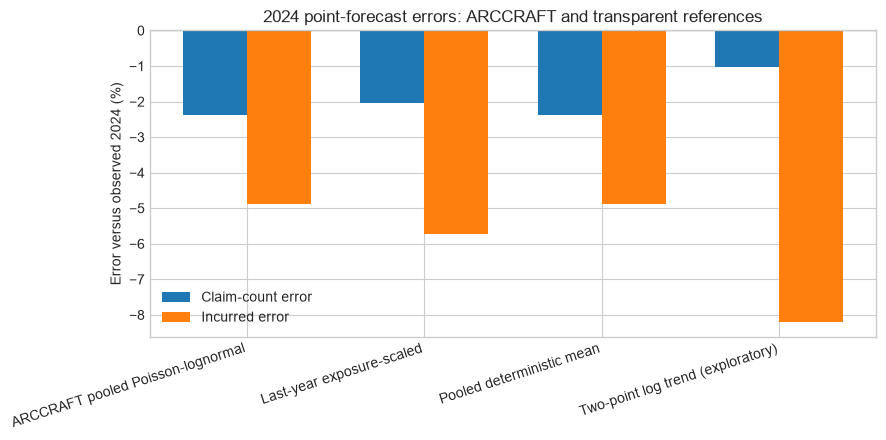

In [5]:
y22, y23, y24 = [annual.loc[annual.year == y].iloc[0] for y in (2022, 2023, 2024)]
arc24 = forecast_outputs[2024]

benchmark_rows = []
def add_benchmark(name, pred_claims, pred_incurred, stochastic=False):
    benchmark_rows.append({
        "model": name,
        "predicted_claims": pred_claims,
        "claim_error_pct": pct_error(pred_claims, y24.claims),
        "predicted_incurred": pred_incurred,
        "incurred_error_pct": pct_error(pred_incurred, y24.incurred),
        "stochastic_interval": stochastic,
    })

add_benchmark(
    "ARCCRAFT pooled Poisson-lognormal",
    arc24["predicted_claim_count"]["mean"], arc24["predicted_incurred"]["mean"], True,
)

last_claims = y24.exposure * y23.claim_frequency
add_benchmark("Last-year exposure-scaled", last_claims, last_claims * y23.avg_severity)

pooled_freq = (y22.claims + y23.claims) / (y22.exposure + y23.exposure)
pooled_sev = (y22.incurred + y23.incurred) / (y22.claims + y23.claims)
pooled_claims = y24.exposure * pooled_freq
add_benchmark("Pooled deterministic mean", pooled_claims, pooled_claims * pooled_sev)

trend_freq = y23.claim_frequency * (y23.claim_frequency / y22.claim_frequency)
trend_sev = y23.avg_severity * (y23.avg_severity / y22.avg_severity)
trend_claims = y24.exposure * trend_freq
add_benchmark("Two-point log trend (exploratory)", trend_claims, trend_claims * trend_sev)

benchmarks = pd.DataFrame(benchmark_rows)
display(benchmarks)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(benchmarks))
w = 0.36
ax.bar(x - w/2, benchmarks.claim_error_pct, w, label="Claim-count error")
ax.bar(x + w/2, benchmarks.incurred_error_pct, w, label="Incurred error")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x, benchmarks.model, rotation=18, ha="right")
ax.set_ylabel("Error versus observed 2024 (%)")
ax.set_title("2024 point-forecast errors: ARCCRAFT and transparent references")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "benchmark_errors_2024.png", dpi=180, bbox_inches="tight")
plt.show()

The deterministic references are not claimed as fully specified competing actuarial models. They are deliberately simple checks on whether the stochastic implementation improves the central estimate. The two-point trend uses only 2022 and 2023 and is therefore labelled exploratory. Predictive intervals are available only for the ARCCRAFT frequency–severity implementation.

## 4. Frequency–severity stress surface

severity_multiplier,0.750000,1.000000,1.250000,1.500000,1.750000
frequency_multiplier,,,,,
0.750000,0.399480,0.532692,0.665848,0.799114,0.932146
1.000000,0.532714,0.710304,0.887654,1.065213,1.242795
1.250000,0.665816,0.887750,1.109854,1.331564,1.553542
1.500000,0.798901,1.065281,1.331903,1.598179,1.864270
1.750000,0.932160,1.242852,1.553603,1.864229,2.175203


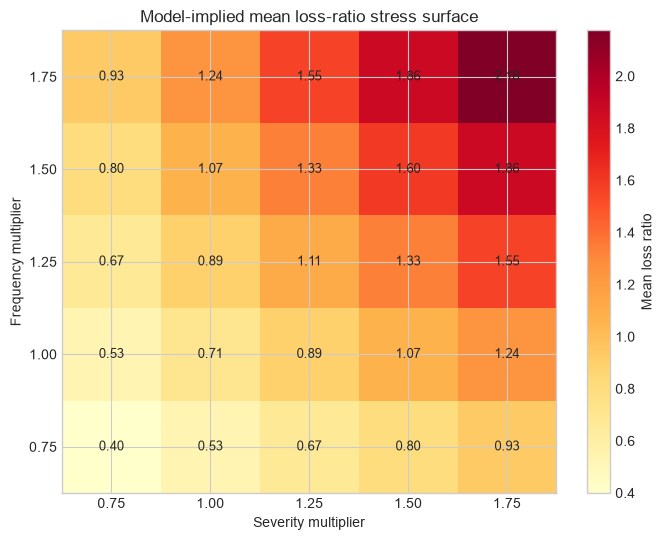

In [6]:
multipliers = [0.75, 1.00, 1.25, 1.50, 1.75]
stress_rows = []
for i, fm in enumerate(multipliers):
    for j, sm in enumerate(multipliers):
        out = arccraft_empirical_motor(
            2022, 2023, 2024, n_simulations=20_000,
            seed=10_000 + i * 100 + j,
            frequency_multiplier=fm, severity_multiplier=sm,
        )
        lr = out["predicted_loss_ratio"]
        # For this implementation LR > 1 can be recovered by re-simulation from
        # the same documented moments; the analytical normal tail is sufficient
        # at the very large aggregate claim counts used here.
        mean, q025, q975 = lr["mean"], lr["q025"], lr["q975"]
        if q975 <= 1:
            p_gt_1 = 0.0
        elif q025 >= 1:
            p_gt_1 = 1.0
        else:
            # Explicit simulation for the boundary cells only.
            cal = out["calibration"]
            target = out["observed_projection_year"]
            rng = np.random.default_rng(50_000 + i * 100 + j)
            counts = rng.poisson(target["exposure"] * cal["claim_frequency"] * fm, 20_000)
            mu = cal["severity_proxy"]["mu_log"] + math.log(sm)
            sigma = cal["severity_proxy"]["sigma_log"] or 0.0
            sev_mean = math.exp(mu + 0.5 * sigma**2)
            sev_var = (math.exp(sigma**2) - 1) * math.exp(2 * mu + sigma**2)
            incurred = np.maximum(rng.normal(counts * sev_mean, np.sqrt(counts * sev_var)), 0)
            p_gt_1 = float(np.mean(incurred / target["premium"] > 1))
        stress_rows.append({"frequency_multiplier": fm, "severity_multiplier": sm,
                            "mean_loss_ratio": mean, "q025": q025, "q975": q975,
                            "p_loss_ratio_gt_1": p_gt_1})

stress = pd.DataFrame(stress_rows)
surface = stress.pivot(index="frequency_multiplier", columns="severity_multiplier", values="mean_loss_ratio")
display(surface)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(surface.values, origin="lower", cmap="YlOrRd", aspect="auto")
for r in range(surface.shape[0]):
    for c in range(surface.shape[1]):
        ax.text(c, r, f"{surface.iloc[r, c]:.2f}", ha="center", va="center", fontsize=9)
ax.set_xticks(range(len(surface.columns)), [f"{x:.2f}" for x in surface.columns])
ax.set_yticks(range(len(surface.index)), [f"{x:.2f}" for x in surface.index])
ax.set(xlabel="Severity multiplier", ylabel="Frequency multiplier", title="Model-implied mean loss-ratio stress surface")
fig.colorbar(im, ax=ax, label="Mean loss ratio")
fig.tight_layout()
fig.savefig(FIG / "stress_surface.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Synthetic engine: replay, validation, and Failure Atlas

In [7]:
def run_synthetic(seed, n=N_SYNTHETIC, strict_repair=False):
    streams = engine.construire_flux_nommes(seed)
    worlds = engine.generer_mondes(streams["world"], n=n)
    validation = engine.valider_mondes(worlds)
    if strict_repair:
        strict_status = validation.statut.copy()
        strict_status[strict_status == "REPAIR"] = "REJECT"
        validation = engine.ResultatValidation(
            statut=strict_status,
            etat_valide={k: v.copy() for k, v in validation.etat_valide.items()},
        )
    before = {k: v.copy() for k, v in validation.etat_valide.items()}
    results = engine.simuler_trajectoires(
        engine.product, worlds, validation, streams["claims"], streams["behaviour"]
    )
    immutable = all(np.array_equal(before[k], validation.etat_valide[k]) for k in before)
    atlas = engine.construire_failure_atlas(results, seed, engine.decrire_flux_nommes(streams))
    return worlds, validation, results, atlas, immutable

wa, va, ra, aa, immutable_a = run_synthetic(MASTER_SEED)
wb, vb, rb, ab, immutable_b = run_synthetic(MASTER_SEED)

same_labels = all(
    (a.regime, a.classe, a.statut_validation, a.porte_ratee) ==
    (b.regime, b.classe, b.statut_validation, b.porte_ratee)
    for a, b in zip(ra, rb)
)
same_values = np.allclose(
    [(r.combined_ratio, r.tracabilite_score) for r in ra],
    [(r.combined_ratio, r.tracabilite_score) for r in rb],
    rtol=0, atol=0, equal_nan=True,
)

wc, vc, rc, ac, immutable_c = run_synthetic(MASTER_SEED + 1)
ws, vs, rs, ast, immutable_s = run_synthetic(MASTER_SEED, strict_repair=True)

def summarize(label, validation, results, atlas, immutable):
    accepted = [r for r in results if r.statut_validation != "REJECT"]
    return {
        "configuration": label,
        "PASS": int(np.sum(validation.statut == "PASS")),
        "REPAIR": int(np.sum(validation.statut == "REPAIR")),
        "REJECT": int(np.sum(validation.statut == "REJECT")),
        "accepted": len(accepted),
        "failure_rate_accepted": np.mean([not r.succes for r in accepted]),
        "mean_combined_ratio": np.mean([r.combined_ratio for r in accepted]),
        "mean_traceability": np.mean([r.tracabilite_score for r in accepted]),
        "atlas_rows": len(atlas),
        "input_state_immutable": immutable,
    }

synthetic_summary = pd.DataFrame([
    summarize("repair / master seed", va, ra, aa, immutable_a),
    summarize("repair / alternate seed", vc, rc, ac, immutable_c),
    summarize("strict reject repairs / master seed", vs, rs, ast, immutable_s),
])
display(synthetic_summary)

replay_checks = pd.DataFrame({
    "check": ["same labels and gates", "same floating-point outputs", "validated input remains unchanged"],
    "passed": [same_labels, same_values, immutable_a and immutable_b],
})
display(replay_checks)
assert replay_checks.passed.all()

,configuration,PASS,REPAIR,REJECT,accepted,failure_rate_accepted,mean_combined_ratio,mean_traceability,atlas_rows,input_state_immutable
0,repair / master seed,2397,603,0,3000,0.345667,0.444833,0.922641,1037,True
1,repair / alternate seed,2363,636,1,2999,0.370123,0.444485,0.917154,1111,True
2,strict reject repairs / master seed,2397,0,603,2397,0.352107,0.436762,0.926296,1447,True


,check,passed
0,same labels and gates,True
1,same floating-point outputs,True
2,validated input remains unchanged,True


,failure_gate,count
0,echecs_tracabilite,1037
1,echecs_ratio_combine,0
2,mondes_rejetes_avant_simulation,0


,scenario_class,mondes_acceptes,taux_echec_synthetique,ratio_combine_moyen,statut_usage
0,BASELINE,347,0.000000,0.401986,synthese_centrale
1,ALTERNATIVE,676,0.303254,0.418588,synthese_centrale
2,ADVERSE,1330,0.403759,0.441768,synthese_centrale
3,SEVERE_PLAUSIBLE,358,0.486034,0.514077,synthese_centrale_separable
4,EXPLORATORY,289,0.418685,0.485996,rapporte_separement


,reverse_stress_exact_replay,world_id_perturbation,distance_standardisee,porte_ratee,tracabilite_score,combined_ratio
0,True,196,1.012325,tracabilite,0.932073,0.401745


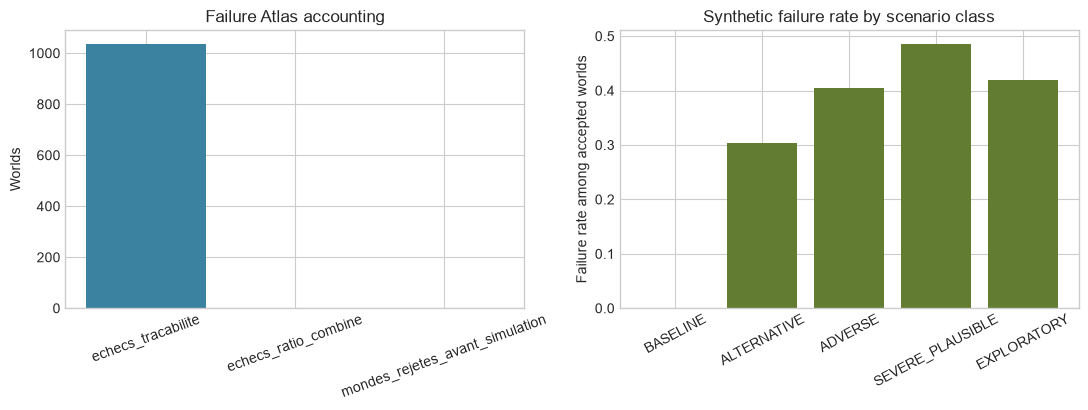

In [8]:
atlas_summary = engine.synthese_failure_atlas(aa)
gate_counts = pd.Series(atlas_summary, name="count").rename_axis("failure_gate").reset_index()
display(gate_counts)

class_report = pd.DataFrame(engine.agreger_par_classe(ra)).T.reset_index(names="scenario_class")
display(class_report)

reverse_1 = engine.recherche_stress_inverse(engine.product, MASTER_SEED)
# Consume unrelated streams, then repeat: the result must be invariant.
unrelated = engine.construire_flux_nommes(MASTER_SEED)
_ = unrelated["world"].normal(size=10_000)
_ = unrelated["claims"].poisson(5, size=10_000)
reverse_2 = engine.recherche_stress_inverse(engine.product, MASTER_SEED)
reverse_replay = reverse_1 == reverse_2
display(pd.DataFrame([{"reverse_stress_exact_replay": reverse_replay, **(reverse_1 or {})}]))
assert reverse_replay

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(gate_counts.failure_gate, gate_counts["count"], color=["#3b82a0", "#b5483a", "#777777"])
axes[0].set(title="Failure Atlas accounting", ylabel="Worlds")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(class_report.scenario_class, class_report.taux_echec_synthetique, color="#627d32")
axes[1].set(title="Synthetic failure rate by scenario class", ylabel="Failure rate among accepted worlds")
axes[1].tick_params(axis="x", rotation=28)
fig.tight_layout()
fig.savefig(FIG / "synthetic_failure_diagnostics.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Exported result tables

In [9]:
rolling.to_csv(OUT / "09_ROLLING_ORIGIN_RESULTS.csv", index=False)
benchmarks.to_csv(OUT / "10_BENCHMARK_RESULTS_2024.csv", index=False)
stress.to_csv(OUT / "11_STRESS_SURFACE_RESULTS.csv", index=False)
synthetic_summary.to_csv(OUT / "12_SYNTHETIC_AUDIT_RESULTS.csv", index=False)
class_report.to_csv(OUT / "13_SCENARIO_CLASS_RESULTS.csv", index=False)
gate_counts.to_csv(OUT / "14_FAILURE_ATLAS_COUNTS.csv", index=False)

exports = sorted(p.name for p in OUT.glob("*.csv") if p.name[:2] in {"09", "10", "11", "12", "13", "14"})
exports

['09_ROLLING_ORIGIN_RESULTS.csv',
 '10_BENCHMARK_RESULTS_2024.csv',
 '11_STRESS_SURFACE_RESULTS.csv',
 '12_SYNTHETIC_AUDIT_RESULTS.csv',
 '13_SCENARIO_CLASS_RESULTS.csv',
 '14_FAILURE_ATLAS_COUNTS.csv']

## 7. Takeaways and limits

- The portfolio file passes database-integrity, critical-null, non-negativity, and duplicate insured-year checks.
- The rolling-origin exercise has only two evaluation years. It supports reporting individual forecast errors, but it cannot establish stable calibration or 95% coverage.
- The 2024 observed outcome is compared directly with the simulated interval. If it falls outside, predictive validation is explicitly not claimed.
- The frequency–severity surface identifies model-implied economic failure regions. It does not show that the selected joint shocks are regulator-defined, historically calibrated, or causally plausible.
- Exact same-seed replay, immutable validated inputs, reverse-stress independence, and complete reject accounting are software-verification results. They do not validate the synthetic world grammar.
- Strict rejection of repairable worlds changes the selected scenario population. The comparison is a validator-sensitivity diagnostic, not an estimate of real-world model risk.
- Stronger claims require more evaluation years or an additional public portfolio, comparator models fitted under the same information set, calibration diagnostics, and tail-focused scoring rules.